1) Importamos librerías

In [8]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 
import pandas as pd

from utils import *

from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

from tslearn.datasets import UCR_UEA_datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

2) Definimos funciones

In [20]:

def load_twolead_ecg():
    """
    Loads TwoLeadECG dataset from UCR archive.
    Returns:
        X: signals (n_samples, time_length)
        y: labels (binary)
    """
    ucr = UCR_UEA_datasets()
    X_train, y_train, X_test, y_test = ucr.load_dataset("TwoLeadECG")

    X = np.concatenate([X_train, X_test], axis=0)
    y = np.concatenate([y_train, y_test], axis=0)

    return X, y


def signal_to_curve(signal):
    """
    Converts 1D time series into 2D curve safely.
    """
    signal = np.array(signal).astype(float).squeeze()  # 🔴 clave

    t = np.arange(len(signal)).astype(float)

    # normalize
    x = (t - np.min(t)) / (np.max(t) - np.min(t) + 1e-8)
    y = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)

    return x, y


def build_dataset_from_ecg(layer, n_points=400):
    """
    Builds PET dataset from TwoLeadECG.
    """
    X_raw, y_raw = load_twolead_ecg()

    X_pet = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        # convert signal to geometric curve
        x, y = signal_to_curve(signal)

        # resample to fixed number of points (important for PET stability)
        idx = np.linspace(0, len(x) - 1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pet, _ = compute_pet_from_shape(x, y, layer)

        X_pet.append(pet)
        y_labels.append(int(label))

    return np.array(X_pet), np.array(y_labels)


def experiment_ecg(layer, n_points=400):

    print("\n=== PET Classification on TwoLeadECG ===")

    X, y = build_dataset_from_ecg(layer, n_points=n_points)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0, stratify=y
    )

    clf = SVC(kernel="linear")
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print("Accuracy:", acc)

    return acc

def plot_two_signals(X, y):
    """
    Plots one example per class from TwoLeadECG.
    """

    X = np.array(X)
    y = np.array(y)

    # find one sample per class
    idx_class_0 = np.where(y == 1)[0]
    idx_class_1 = np.where(y == 2)[0]

    sig0 = np.squeeze(X[idx_class_0])
    sig1 = np.squeeze(X[idx_class_1])

    t0 = np.arange(len(sig0))
    t1 = np.arange(len(sig1))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(t0, sig0)
    plt.title("TwoLeadECG - Class 1")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.plot(t1, sig1)
    plt.title("TwoLeadECG - Class 2")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles

3) Vemos el dataset

In [ ]:
X, y = load_twolead_ecg()

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

dict(zip(unique, counts))


(1162, 82, 1)
(1162,)


{np.int64(1): np.int64(581), np.int64(2): np.int64(581)}

1162 señales de longitud 82, con una muestra balanceada: 581 ecg clasificadas en tipo 1 y 581 clasificadas en tipo 2. Tipo 1 es latidos con patron normal, tipo 2 es latido con morfologia istinta.

4) Visualizamos señales de ambos tipos

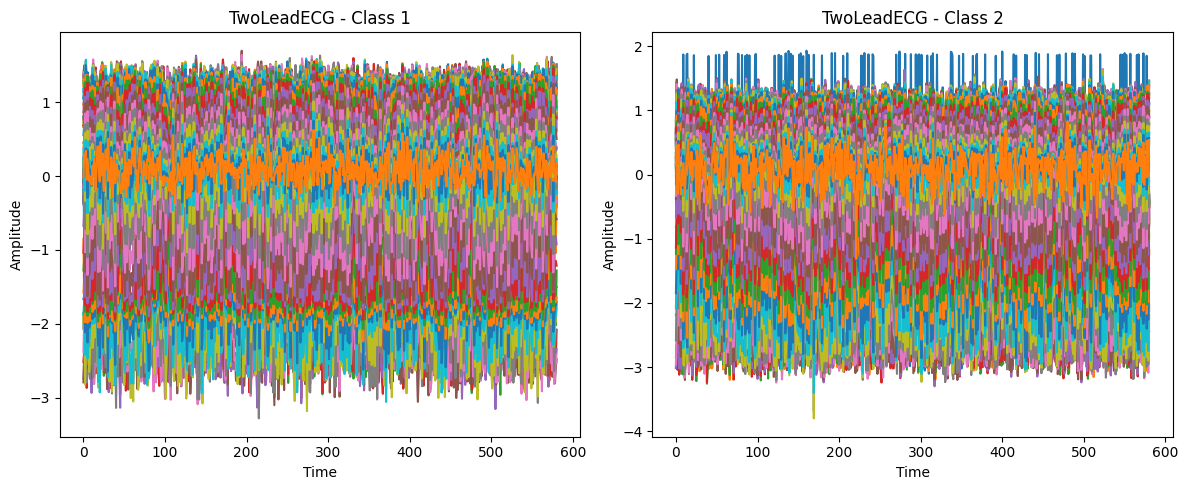

In [18]:
plot_two_signals(X,y)

5) Run SVM using PET as input data

In [21]:
n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_ecg(layer, n_points=n_points)


=== PET Classification on TwoLeadECG ===
Accuracy: 0.994269340974212


0.994269340974212